# Point Cloud Tangles
(Michael Hermann)

A *Tangle* is a concept from graph theory useful to characterize densely connected sub-structures in graphs. In recent years, the graph based theory of tangles was adapted to more and more different data structures and finally cast into a data analytics technique. This notebook will provide a friendly introduction to one of the most simple things one can do with *Tangles*: **Soft Clustering** of points in $\mathbb{R}^2$.

We start with a short reminder on clustering and tangle theory and proceed with an in depth discussion of an example tangle analysis. The example is a *toy example* but can serve as a proof of concept and a nice introduction into tangle soft clustering.

## 1. Clustering and Tangles
We are living in an era of data. More and more aspects of our daily lives are influenced by algorithms driven by big collections of data. Thousands of companies, institutions and individuals are collecting massive amounts of data from an unconceivable multiplicity of different sources. The collectors' motivation might sometimes not be the most descent - often the motivation is merely a capitalistic one - and maybe even more often, the collectors might not even know their own motivation, yet. In times of big data, miniscule storage costs allow to generate, collect and store data without any purpose just because it might contain something interesting that could be useful in the future. Finding out if such a data set contains anything interesting is the goal of *unsupervised learning*, a data analysis task aiming to detect patterns in unlabeled data. A very important and maybe the conceptually easiest task in unsupervised learning is *clustering*. 

### 1.1 Clustering - let's divide
The objective of clustering is to divide a set of objects $V$ into a number of subsets $C_i \subseteq V, 1 \leq i \leq k$, called *clusters*, so that objects sharing the same cluster are in some sense similar, i.e. they somehow belong together, and objects in different clusters tend to be dissimilar. This definition is kind of abstract and there are many different ways to formulate concrete clustering objectives. We will not dive into the details but want to describe one very basic distinctive property of clustering algorithms and their results: In *hard clustering*, the clusters $C_i$ form a *partition* of $V$, i.e. the data set $V = \dot{\bigcup}_i C_i$ is a *disjoint union* of the clusters. This means, every point $v \in v$ belongs to one and only one cluster. In *soft clustering* every data point is allowed to belong to multiple clusters. Usually, a soft clustering result assigns a *grade of membership* of every point to every cluster and an overall structure is captured in a *fuzzy* way by the differences in these membership grades. Usually soft clustering algorithms are computationally more expensive, but they have the advantage that their results often allow to assign a certain form of *confidence* in the result. For example, there might be points lying between two relatively obvious clusters. A hard clustering algorithm has to decide for one of the clusters while a soft clustering algorithm can stay indifferent if the cluster assignment cannot be done with high confidence: These data points could belong with high confidence to the two cluster aggregate, but with low confidence to one of them in isolation.

### 1.2 Tangles - let's work together
Every clustering algorithm trys to detect a *structure* within the data by dividing the set into subsets describing relations between the elements on a more global level. *Tangles* have the similar goal to detect structure in a data set but operate in a significantly different way.
While clustering usually creates a single partition of the data reflecting its internal structure, tangles start with a set of partitions and describe the data using a particular way to combine information from multiple such partitions. 
In the following, we will try to shortly summarize the idea. A full treatment of all the theory's beauty and complexity would go beyond the scope of this notebook. Please have a look at the [tangles book](http:www.tangles-book.com) for a deeper understanding of the complete picture and discussions of many more interesting ideas.

### 1.3. Features - choose your side
Suppose you have a set consisting of multiple (usually cheaply obtained) bipartitions of a data set $V$. Every bipartition $V = A \cup B$ with $A \cap B = \emptyset$ can be represented by fixing one of the partition classes $A$ or $B = A^c$, where $A^c = V \setminus A$ is the complement of $A$ in $V$. We can interpret every bipartition of $V$ as a *feature* that every data point either *has* or *not has*. If a data point $v \in V$ does not have a feature $A$, this means if $v \notin A$, then we say $v$ has the *inverse feature*, i.e. $v \in A^c$. We call every two-element set $F = \{A, A^c\}$ a *potential feature* in $V$ and its *sides*, $A$ and $A^c$, *specifications* of $F$.
In the theory of tangles, a structure within a set can be an arbitrarily abstract concept, especially, such a structure does not need to be representable as a single subset or a collection of multiple subsets of $V$. Let's suppose there is some abstract, hard to describe (sub-)structure in $V$. Then for every potential feature $F = \{A, A^c\}$ of $V$ there are exactly three possibilities:
- most of the substructure is covered by the feature $A \subset V$. If we look at $A$ alone, the interesting structure (or a significant part of it) can still be recognized.
- most of the substructure is covered by the inverse feature $A^c$, and the structure (or a significant part of it) can still be identified within this subset
- the bipartition $\{A, A^c\}$ *shatters* the interesting structure. The structure can neither be recognized in $A$ nor in $A^c$ if we look at these subsets in isolation.

### 1.4. Order functions - not all features are created equal
A crucial fact regarding features on $V$ is that not all of them are equally descriptive for a particular structure on $V$, independent of how this structure is defined or typified. Most potential features of $V$ will not have anything to do with any interesting structure - these are features falling in the third category above - but other features are possibly able to capture *some aspects* of an interesting structure. 
Suppose, for simplicity, we can actually describe a part of an interesting substructure on $V$ by a bunch of prototypical elements $R \subset V$ and let $\{A, A^c\}$ be a potential feature that is able to capture aspect of this structure. Then we should expect most of the elements of $R$ to either be in $A$ or in its complement $A^c$ - either the *presence* or the *absence* of the feature $A$ is significant for most of the elements of $R$ and therefore the structure depicted by $R$.

The tangles-way to quantify the capability of a feature to capture aspects of a significant structure is to define an *order function* $o:2^V \rightarrow \mathbb{R}$. Such an order function assigns lower values to features that can be expected to be more descriptive of the structure in $V$. We usually require from the order function $o$ additionally that every feature has the same order as its inverse. 
In practice, we rarely interpret the numerical value of an order function - even if we could do this for a lot of examples - but we use the function solely to sort a set of features $S$ by increasing order with the goal to create a hierarchical system of nested subsets $\emptyset = S_0 \subset S_1 \subset S_2 \subset \dots \subset S_n = S$. Please note, that order functions are not required to be injective and therefore the sorting of $S$ is not unique. This fact is merely an annoyance when describing related concept and can satisfyingly be treated in theory and practice, therefore we often handle order functions *as if they were injective*. 

In general, the concept of "powerful features" and "order functions" is problematic: Usually we neither know the structures we want to detect nor do we know exactly how to evaluate a feature's power to detect aspects of these unknown structures. Therefore, we have to find a different strategy to define order functions. Such a strategy will usually depend on the data and the context or the question that is supposed to be answered by the analysis. 
In the context of clustering, the most natural approach to specify an order function is based on a definition of *point similarity*. Usually one can easily define a function $V \times V \rightarrow \mathbb{R}_{>= 0}$ that takes high values on pairs of very similar data points and zero if the two input data points are completely dissimilar. Let's assume we have such a function and want the tangles to detect structures based on similarities between data points. Then a very natural way to quantify the representative power of a potential feature is to evaluate how similar the data points are inside the same specification and how dissimilar points are that lie in different specifications: A bipartition that can describe structures emerging from point similarities should not separate a lot of similar points.

### 1.5. Consistency - let's agree on one point, at least
Let $S$ be a set of potential features. Then we call a set $\vec S$ that contains exactly one specification of every potential feature in $S$ a *specification* of $S$. Such a specification is called *consistent* if for every subset of three features $\{A, B, C\} \subseteq \vec S$ at least one element in $V$ exists that has all three features, i.e. $A \cap B \cap C \neq \emptyset$ - or, from a dual point of view, if every triple of features agrees on at least one data point.
It is not a rare situation that a consistent orientation satisfies a bit more than the consistency condition alone. If $\vec S$ is a specification of $S$, we call the number $\alpha(\vec S) = \min_{A,B,C \in \vec S} |A \cap B \cap C|$ the *agreement* of $\vec S$. Obviously, a consistent specification $\vec S$ of $S$ satisfies $\alpha(\vec S) > 0$.

We are finally ready to define our most important notion. We will not use the most general definition but the one that is most relevant (and best supported) in praxis: Let $\alpha_{\min} \in \mathbb{N}$ be a fixed number. A *tangle* of a feature system $S$ (with *minimum agreement* $\alpha_{\min}$) is a specification $\vec S$ of $S$ with agreement $\alpha(\vec S) \geq \alpha_{\min}$. The number $\alpha_{\min}$ is usually called the *agreement parameter* or the *minimum agreement*. 

### 1.6. Tangles - sweep the world
If we have decided for a set of potential features $S$ and an agreement parameter $\alpha_{\min}$, we are essentially ready to search tangles of $S$. We need to find every specification of $S$ that satisfies the agreement condition. If $S$ contains $|S|=k \in \mathbb{N}$ features, we merely have to check $2^k$ possible specification and every check of the agreement condition is cubic in $k$. The naive implementation then needs to compute $O(k) = k^3 2^k$ intersections of our features. It's obvious, that this is not tractable for relevant values of $k$ and, equally obvious, that such an implementation is far from the best possible: If we fix the specification $\vec T$ of any 3-subset $T \subseteq S$, there are $2^{k-3}$ specifications of the complete feature set $S$ which contain $\vec T$. The naive implementation would repeat the same work, i.e. checking the agreement of $\vec T$, an exponential number of times - clearly with the same result. The tangle library's implementation therefore approaches the problem in a more structured way. We will not delve into every detail, but there are some side effects of the actual implementation that are worth mentioning.

Let $o: S \rightarrow \mathbb{R}$ be an order function. As anticipated above, we mainly use $o$ to create a hierarchical set system $\{S_i : S_i \subset S_{i+1} 1 \leq i < |S|\}$ where $S_i$ contains the $i$ potential features of $S$ with the smallest order (assuming an injective order function). Then the implemented search algorithm successively finds all tangles of $S_1, S_2, \dots, S_n$. All intermediate results are stored in a (rooted) tree called the *tangle search tree (TST)*. All nodes of this tree represent tangles and every edge between level $i-1$ and $i$ represents a specifications of the $i$-th separation, i.e. the single element of $S_i \setminus S_{i-1}$. 
Let $\tau$ be a tangle of $S_i$. We find the corresponding specification by following the unique path from the root to $\tau$'s node and collecting the specifications associated with the traversed edges. The following image shows an example of a tangle search tree and illustrates the encoding of the specifications.

![A tangle search tree](images/TST.png "A tangle search tree")

To build the tree, we iteratively grow the tangle search tree level by level. If we want to search tangles of $S_{i+1}$ and already have tangles of $S_i$, we simply check all nodes at level $i$, i.e. tangles of $S_i$, if they can be *extended* by one or both of the possible specifications of the potential feature in $S_{i+1} \setminus S_i$. This can be done in very simple way by collecting all 2-tuples of features that appear in at least one of the $S_i$-tangles and checking the agreement condition for all triples that can be obtained by combining every found 2-tuple with one of the new feature's specifications.  
If a tangle of $S_i$ cannot be extended to a tangle of $S_{i+1}$, we call this tangle a *maximal tangle*. It is noteworthy that, in the worst case, we might not run across any maximal tangles at all. Then the number of tangles grows exponentially with the size of $S$ and even an efficient implementation needing only a cubic number of agreement computations will still have exponential complexity. Thankfully, this daunting complexity is not relevant in practice at all: If we find our algorithm to create an exponentially large tangle search tree of for example $S_{20}$, the search can be aborted with good conscience as structures described by millions of tangles rarely satisfy any reasonable kind of inquisitiveness.

The implementation provided by the tangle library is actually much more dynamic than the high level description we have seen in the last paragraph. The implemented algorithm is known under the name *Tangle Sweep*. The tangle sweep allows the agreement parameter to be changed afterward *without needing to rebuild the tangle search tree from ground up*. 
This flexibility is achieved by a slight change to the tree structure. We not only store the nodes that satisfy the currently chosen agreement parameter, but we remember the *first* nodes that *fail* the agreement test. Let's  call these nodes *maximal nodes*. To avoid confusion, a *maximal tangle* then is a node that has two maximal nodes as children. Additionally, we store the agreement value $\alpha(\sigma)$ for every maximal node $\sigma$ in the tree. 
If the externally set agreement parameter falls below the internal agreement value of a maximal node, then the expansion of this node's subtree is initiated similarly as if the tree would have been build with a lower agreement parameter right from the start. 
If the external agreement parameter is increased, the tree just stays the same. If maximal tangles are queried for a higher agreement, we just iterate through all notes and collect the ones that have two children with internal agreement below the query agreement.
The algorithm thus allows to initiate a tangle search with a relatively high agreement parameter, resulting in a fast initial search, and allows to refine the tree by lowering the agreement step by step until a reasonable number of tangles is found. Going back to a higher agreement is always possible without any expensive computations. Please note, that this flexibility necessitates every query to the tree to be parametrised by an agreement parameter. Please consult the software's [documenation](https://tangle-software.github.io/tangles/reference/api/tangles.html) for more details.

### 1.7 Scores - Back to fuzzy clusters
We started our small "tour de tangles" with an introduction to clustering. Let us now close the circle and find out how tangles can be converted to clusters.
The tangle library provides multiple methods to create a soft or hard clustering from a tangle search tree. The simplest way is to directly evaluate a *tangle score* that describes the individual data point's *grade of membership* in a tangle. The tangle scores can be computed by a simple matrix multiplication of a matrix containing the features' indicator vectors as columns and a matrix containing the tangles' orientation vectors as columns. Please consider the software's documentation for further details. 

Tangle scores are especially useful if our data set can be embedded in the 2-dimensional plane in an interpretable way. Then the scores can be visualised appealingly as *heatmaps*. We will see a nice examples in the second part of this notebook.


## 2. Tangle soft clustering in $\mathbb{R}^2$

Let's look at an example. We will first sample some nice data, describe a meaningful order function based on point similarity and finally investigate the tangles of two simple feature sets.

### 2.1. Sampling Data

We will investigate *Tangle Clustering* using a running example, therefore we start with creating sample data. To keep it simple, we sample $1000$ points from a mixture of gaussians,  each gaussian with diagonal covariance matrix. We choose to have a mixture of $15$ 2d-gaussians with mean sampled uniformly in $[0,10)^2$ and standard deviations chosen uniformly from the set $\{0.5,2\}^2$. The mixing weights are sampled uniformly from the interval $[0.25,1]$. The reason why we choose the standard deviations from a set of two fixed values is arbitrary: it appeared to create blobs of gaussian data that look slightly more interesting.

(Feel free to change the parameters and sample different data in the  second pass through this notebook!)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def create_2d_test_data(means, scales, weights, num_samples=1000, return_center_assignment=True):
    if len(scales.shape) == 1:
        scales = scales[:,np.newaxis]
    sel = np.random.choice(means.shape[0], size=num_samples, replace=True, p=weights/weights.sum())
    sel = sel[sel.argsort()]
    data = means[sel,:] + np.random.normal(size=(num_samples,2))*scales[sel,:]
    data -= data.mean()
    if return_center_assignment:
        return data, sel
    else:
        return data

np.random.seed(23)

n_centers = 15
M, centers = create_2d_test_data(means=10*np.random.random(size=(n_centers, 2)), 
                                 #scales=0.5*np.ones((n_centers, 2)) + 0.5*np.random.random(size=(n_centers,2)),
                                 scales = np.random.choice([0.5,2], size=(n_centers,2)),
                                 weights=0.25 + 0.75*np.random.random(size=n_centers),
                                 num_samples=1000)


Let's plot the sampled data and investigate it visually:

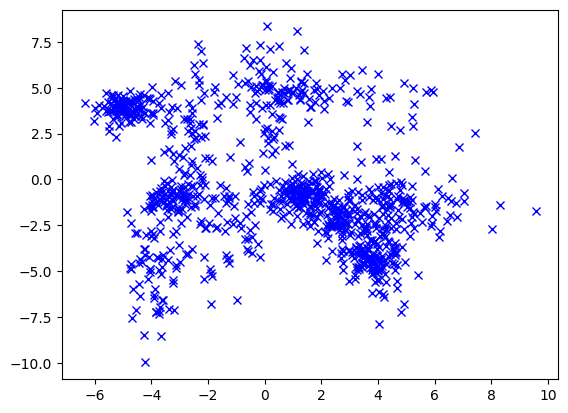

In [15]:
plt.plot(M[:,0], M[:,1], "xb");

This looks good - not too easy, not too hard :-) The $15$ clusters from the sampling process can not really be recognized. The cluster structure looks *hierarchical*: There are four clusters on highest level that should be very easy to detect. At least two of these high level clusters seem to be composed of multiple smaller clusters. Refining the clusters further could be difficult.  

If the data is sorted in a meaningful way, it is often insightful to plot a distance matrix. We compute this matrix and store it in a variable `distances` as we will also use it later to compute similarities between the data points.
Please note, that sorting the points in such a way - data points sampled from the same gaussian are stored next to each other - would be very difficult in a situation where we want to analyse real data obtained from unknown distributions. If we could sort the matrix in a similar way, we would have solved the clustering problem. In other words: We need the data's structure to sort the matrix in this way, and, the other way round, if we can sort the matrix in this way, we know the structure...

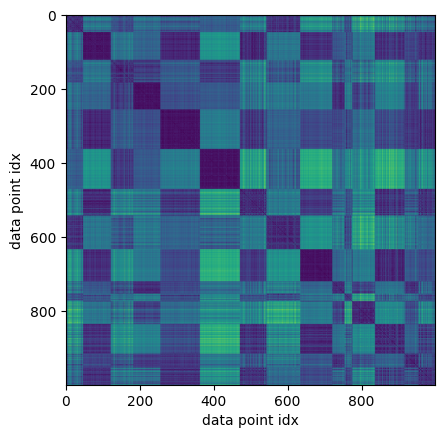

In [16]:
from scipy.spatial import distance_matrix
distances = distance_matrix(M,M)

plt.imshow(distances)
plt.xlabel("data point idx")
plt.ylabel("data point idx");

Interestingly, one can clearly identify the $15$ gaussian blobs, even if one cannot recognize these as clusters in the scatter plot of the data.
Visually, some of the clusters can be separated more clearly from the remaining data. We can expect our algorithm to have an easier life on some of the clusters and may have difficulties with others. The hierarchical nature of the cluster structure can be guessed vaguely, but is not obvious.

### 2.2. An order function based on point similarity

We compute a simple order function based on the distance matrix. This order function creates a sparse similarity matrix with entries depending on the point distances in a quite obvious way: Close points are similar, distance points are dissimilar. To be exact, if $D \in \mathbb{R}^{V \times V}$ is the distance matrix and $t \in \mathbb{R}_{\ge 0}$ is a threshold parameter, the entries of the similarity matrix $K \in \mathbb{R}^{V \times V}$ are computed as
 
$$K(u,v) = 1 - \frac{\min(D(u,v), t)}{t}$$

that is, if the distance between two separated points is inside the interval $[0,t)$, the similarity decreases linearly from $1$ to $0$ with distance increasing from $0$ to $t$, if the distance is greater or equal to $t$, the similarity is $0$. 

The tangle library provides the convenience function [linear_similarity_from_dist_matrix](https://tangle-software.github.io/tangles/reference/api/tangles.util.matrix_order.linear_similarity_from_dist_matrix.html) to compute similarity matrices of this kind.

Depending on the threshold parameter $t$, the resulting matrix can be very sparse - a very good reason to prefer similarity matrices over distance matrices if workingon bigger data sets. 

Finally, the order function is given by the *matrix order function* based on the negation of the similarity matrix $K$. Let $f \in \{-1,1\}^{V}$ be the *feature indicator vector* of the potential feature $\{A, A^c\}$, this means $f(v) = 1$ if $v \in A$ and $f(v) = -1$ otherwise. Then the order of $f$ is computed as the quadratic form

$$ o(f) = - f^T K f.$$

This expression evaluates (and accumulates) the similarity of points on different sides of the bipartition $\{A, A^c\}$. A feature's order is smaller if it separates fewer similar points.

Let's try to visualise an example of the order computation. 
It is helpful to take a different perspective on the order function. We can interpret the function as some kind of *matrix order approximation* to the loss function of a classifier evaluating points within a *margin* around an imaginary decision boundary between a bipartition's sides.

The plot shows a feature splitting the data set into two classes shown in red and blue. The decision boundary between red and blue points is approximated by a negligently regularized *support vector machine* and drawn as a thick black line. The order function depends only on separated pairs of points that are close to the decision boundary. The members of such pairs are connected by a line. The order depends on the sum of the lengths of these lines.

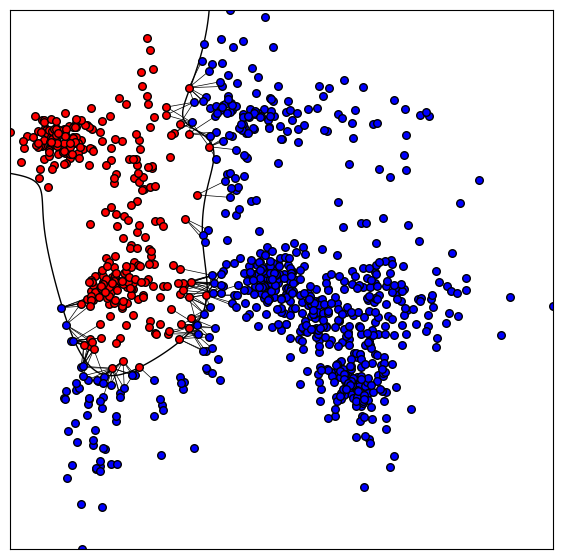

In [17]:
from point_clouds_helpers import plot_margin_example
plt.figure(figsize=(7,7))
plot_margin_example(M,(distances[np.isin(centers,[2,5]),:]<1.3).any(axis=0), margin=1.0, C=1e6, ax=plt.gca())
plt.xticks([])
plt.yticks([]);

This order functions seems to make sense, but it has a suboptimal side effect: Unbalanced features, i.e. potential features where one specification has significantly smaller size than the other, tend to have lower order. This effect can be reduced by decreasing the margin size, but we cannot get rid of it completely. Having said that, this effect is not only bad: If the data set fades from a conglomerate of dense clusters to sparse regions at the border, the *outlier* points are not tightly related to the dense clusters and a feature describing these outlier points should not have high order.  

Let's use the final cell of this section to do the technical stuff. We create the similarity matrix and a `lambda` expression that computes the matrix order function based on the negated similarity matrix:

In [18]:
from tangles.util.matrix_order import linear_similarity_from_dist_matrix

sim_matrix = linear_similarity_from_dist_matrix(distances, margin=1.5, sparse_mat=False)
order_fun = lambda seps: -(seps * (sim_matrix @ seps)).sum(axis=0)

### 2.3. Tangles of a simple feature system

We are now ready to search tangles. We propose a very simple feature set that might appear naive but will work quite well. We start with $k$ equidistant horizontal and $k$ equidistant vertical lines through the data's support and create one potential feature per line. Each feature splits the data set in a subset of points below, or left, and a subset of points above, or right, of the line.

We choose $k=100$ horizontal and vertical lines, respectively:

In [19]:
k=50
S_ax = -np.ones((M.shape[0], 2*k), dtype=np.int8)
for i,t in enumerate(np.linspace(M[:,0].min(), M[:,0].max(), k+2)[1:-1]):
    S_ax[M[:,0]<t,i] = 1 
for i,t in enumerate(np.linspace(M[:,1].min(), M[:,1].max(), k+2)[1:-1]):
    S_ax[M[:,1]<t,k+i] = 1 

We are not primarily interested in the splitting lines but in the resulting bipartitions of $V$. Not every line results in a unique bipartition, therefore we remove duplicates. Afterward, we sort by the order function defined in the last chapter:

In [20]:
from tangles.util import unique_cols
S_ax = unique_cols(S_ax*S_ax[0:1,:])
S_ax = S_ax[:,order_fun(S_ax).argsort()]

print(f"There are {S_ax.shape[1]} unique features left")

There are 92 unique features left


That is not a very big number of features, so we can investigate them all at once:

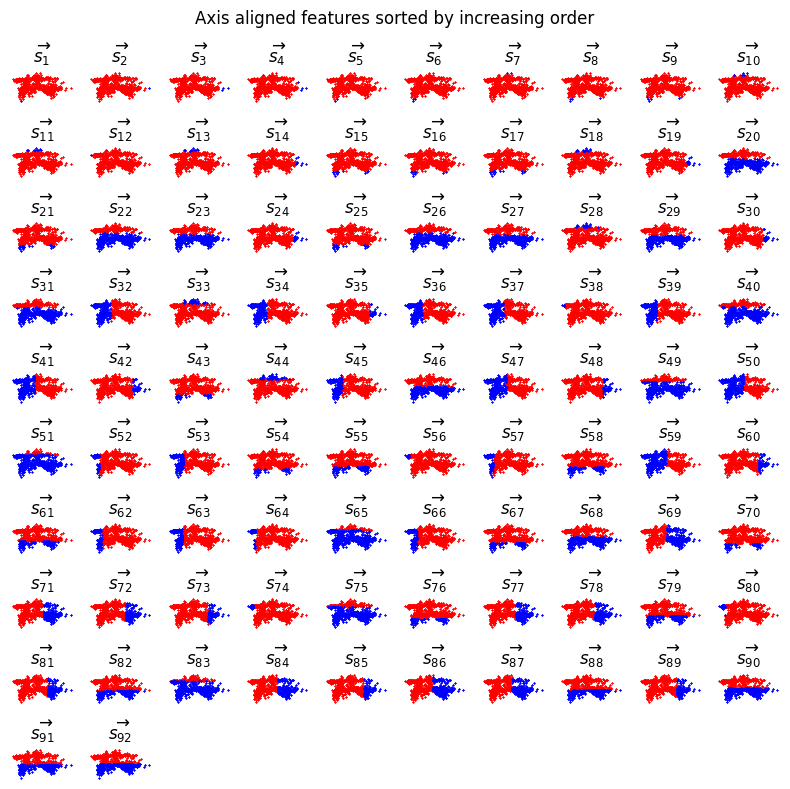

In [21]:
fig, axes = plt.subplots(nrows=10,ncols=10, figsize=(8,8))
for i,ax in enumerate(axes.flat):
    if i < S_ax.shape[1]:
        ax.plot(M[S_ax[:,i]>0,0], M[S_ax[:,i]>0,1], "xr", markersize=1)
        ax.plot(M[S_ax[:,i]<=0,0], M[S_ax[:,i]<=0,1], "xb", markersize=1)
        ax.set_title(r"$\overrightarrow{{s_{{{0}}}}}$".format(i+1))
        ax.axis("off")
    else:
        ax.set_visible(False)
fig.suptitle("Axis aligned features sorted by increasing order")
fig.tight_layout()

Most features do not look very helpful. A lot of them cut of a few outliers at the borders, i.e. are quite *unbalanced*, some cut straight through very dense regions. A small number of features seems to distinguish left from right and top from bottom in a reasonable way. We can expect the tangles to find at least the four obvious clusters at the top left, top, right, bottom left and bottom right.

It seems that *some* features capture *some* aspects of the data's structure. This is exactly where the order function comes into play: The "good" features are mixed into a range of less promising ones at "moderately" low order. The features $\overrightarrow{s_1}, \dots, \overrightarrow{s_{19}}$ describe outliers at the borders, at $\overrightarrow{s_{20}}$ the top is separated from the bottom and at $\overrightarrow{s_{32}}$ the left is distinguished from the right. The features of high order seem to cut through quite dense areas, mostly.


Ok, let's just try it out. We have a very small and simple feature set, therefore we can afford to search tangles with a low agreement of $10$. The library provides a [convenience function](https://tangle-software.github.io/tangles/reference/api/tangles.convenience.search_tangles.html) to handle simple cases like this:

In [37]:
from tangles.convenience import search_tangles, DefaultProgressCallback
tangles = search_tangles(S_ax, min_agreement=10, progress_callback=DefaultProgressCallback(show_info_while_running=False))

[ tree height=92, number of tangles=118, limit=9.0 ]: appending finished                                                                              


For an agreement parameter this low, the search results in $118$ tangles. Obviously, the agreement is too low to make sense. We don't want to split our data set of $1000$ points into more than $100$ fuzzy clusters. Thankfully, the *TangleSweep* algorithm allows us to increase the agreement parameter without rebuilding the tree.

Let's try a bigger agreement parameter and look at the tangles search tree. The tangle library provides a [function](https://tangle-software.github.io/tangles/reference/api/tangles.util.tree.BinTreeNetworkX.draw.html) to draw the tangle search tree. The plot is a bit more complex, let's draw it first and walk through the details afterward:

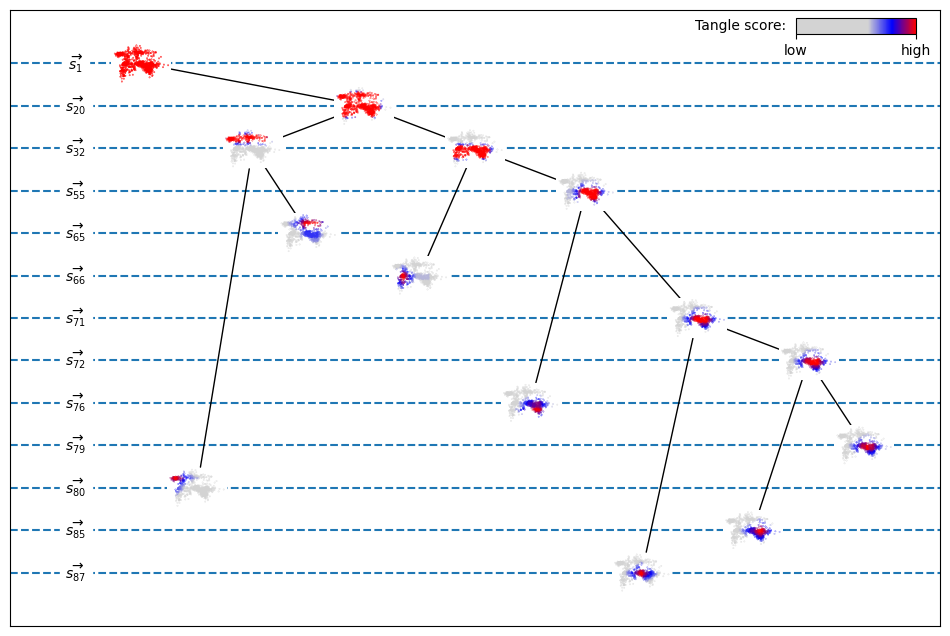

In [50]:
from tangles.util.tree import BinTreeNetworkX
from tangles.analysis import tangle_score
import matplotlib.patches as patches
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

agreement = 30

c = ["lightgray", "lightgray", "blue", "red"]
v = [0,0.6,0.8,1.0]
cmap=LinearSegmentedColormap.from_list('mymap',list(zip(v,c)))

def draw_tangle(G, node_id, ax):
    bin_tree_node = G.nodes[node_id][BinTreeNetworkX.node_attr_bin_tree_node]
    min_p, max_p = (M[:,0].min()-1, M[:,1].min()-1), (M[:,0].max()+1, M[:,1].max()+1)
    ax.set_xlim(xmin=min_p[0], xmax=max_p[0])
    ax.set_ylim(ymin=min_p[1], ymax=max_p[1])
    ax.add_patch(patches.Rectangle(min_p, max_p[0]-min_p[0], max_p[1]-min_p[1], edgecolor='none', facecolor='w'))
    if bin_tree_node.parent is None:
        ax.scatter(M[:,0],M[:,1], c=np.ones(M.shape[0]), s=0.1, vmin=-1000, vmax=1, cmap=cmap)
    else:
        path = np.array(bin_tree_node.path_from_root_indicator())[np.newaxis,:]
        scores = tangle_score(path, tangles.tree.sep_ids[:path.shape[1]], tangles.sep_sys).reshape(-1)
        ax.scatter(M[:,0],M[:,1], c=scores, s=0.05, cmap=cmap)

bintree = BinTreeNetworkX(tangles.tree.maximal_tangles(agreement=agreement, include_splitting='nodes'))

fig, ax = plt.subplots(1,1,figsize=(12,8))
bintree.draw(draw_node_label_func=draw_tangle, draw_edge_label_func=None, ax=ax, node_label_size=0.05, draw_levels=True, 
             level_label_func=lambda l: r"$\overrightarrow{{s_{{{0}}}}}$".format(l+1))

ax2  = fig.add_axes([0.78,0.85,0.1,0.02])
ax2.set_ylabel("Tangle score: ", rotation="horizontal", horizontalalignment="right", verticalalignment="center")
cb  = mpl.colorbar.ColorbarBase(ax2,cmap=cmap,norm=mpl.colors.Normalize(vmin=0,vmax=1),orientation='horizontal')
cb.set_ticks([0,1])
cb.set_ticklabels(["low", "high"])

The plot shows a part of the tangle search tree. The complete tangle search tree is usually too big to be drawn while including all relevant details. Therefore, we extract only maximal tangles and so-called *splitting nodes*, these are non-maximal nodes that have two children, i.e. tangles that are split into two new tangles by the next feature. The nodes are drawn as miniature versions of the data set where the points' tangle scores are indicated by color. Every leaf corresponds to a maximal tangle, so we have seven maximal tangles in total. The two tangles in the left subtree show clustesr in the top left and in the top right. The other subtree is a bit more complicated. First, a cluster in the lower left is separated, the lower right part is further refined into four clusters showing a particular hierarchical arrangement. 

The dotted horizontal lines show the levels of the tree. The levels are labeled by the first feature that is specified *directly after the drawn nodes*. The root corresponds to the complete data set. The first feature branching into the data set's lower and upper part is $\overrightarrow{s_{20}}$. The node immediately before the branch shows a high tangle score for nearly every point except some outlier points close to the border. The exact specification of the features before, $\overrightarrow{s_{1}}, \dots, \overrightarrow{s_{19}}$, cannot be seen in the tree, all we know is, that the tree does not branch anywhere at these levels. The same applies to all other lines that skip multiple levels: for example, both subtrees of the node before $\overrightarrow{s_{32}}$ are *paths*, i.e. all their nodes have degree $2$, but the left path and the right path might encode different specifications of the potential features $s_{33}$ to $s_{65}$.

The plot of the tangle search tree gives a good overview over the tangles and their hierarchical relationships, but the details of the tangle scores are not perfectly visible. The details can better be seen if we give the tangle scores a bit more space:

We use the same agreement as above:

Text(0.5, 0.98, 'Maximal tangles for agreement 30')

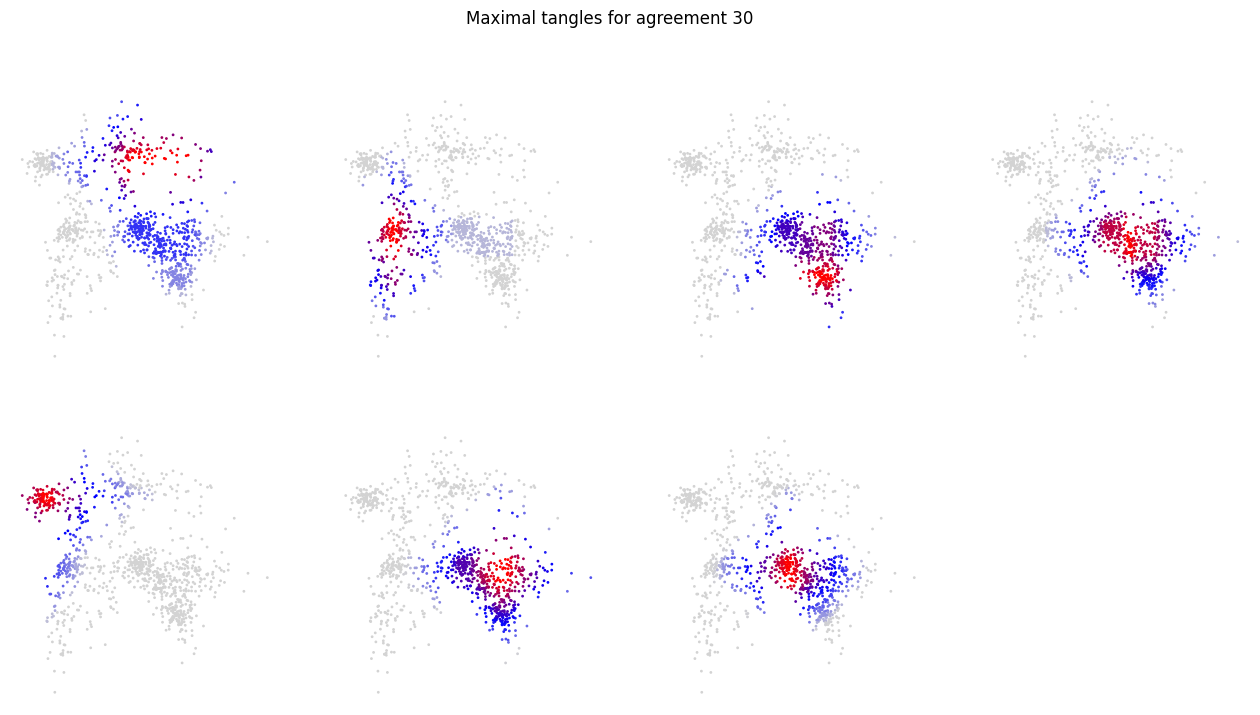

In [51]:
scores = tangles.tangle_score(min_agreement=agreement, normalize='cols')
fig, axes = plt.subplots(nrows=(r:=int(np.ceil(scores.shape[1]/4))), ncols=4, figsize=(16,r*4))
for i,ax in enumerate(axes.flat):
    if i<scores.shape[1]:
        ax.scatter(M[:, 0], M[:, 1], c=scores[:, i], s=1, cmap=cmap)
        ax.axis("off")
    else:
        ax.set_visible(False)
fig.suptitle(f"Maximal tangles for agreement {agreement}")

The scores look mostly reasonable. The upper part of the cluster aggregation on the bottom right seems not to be separated very clearly.

Next, we want to investigate the influence of the agreement parameter. We already have seen that we get way too many tangles for $\alpha_{\min} = 10$ and a quite reasonable number of tangles for $\alpha_{\min} = 30$. Let's investigate some more values:

The next plot shows the number of tangles for an agreement parameter varying in the range $[20,150]$. At some agreement levels, the plot shows the corresponding set of maximal tangles. The visualisation is the same as in the last plot: each tangle is visualised as a heatmap on a miniature version of the complete dataset.

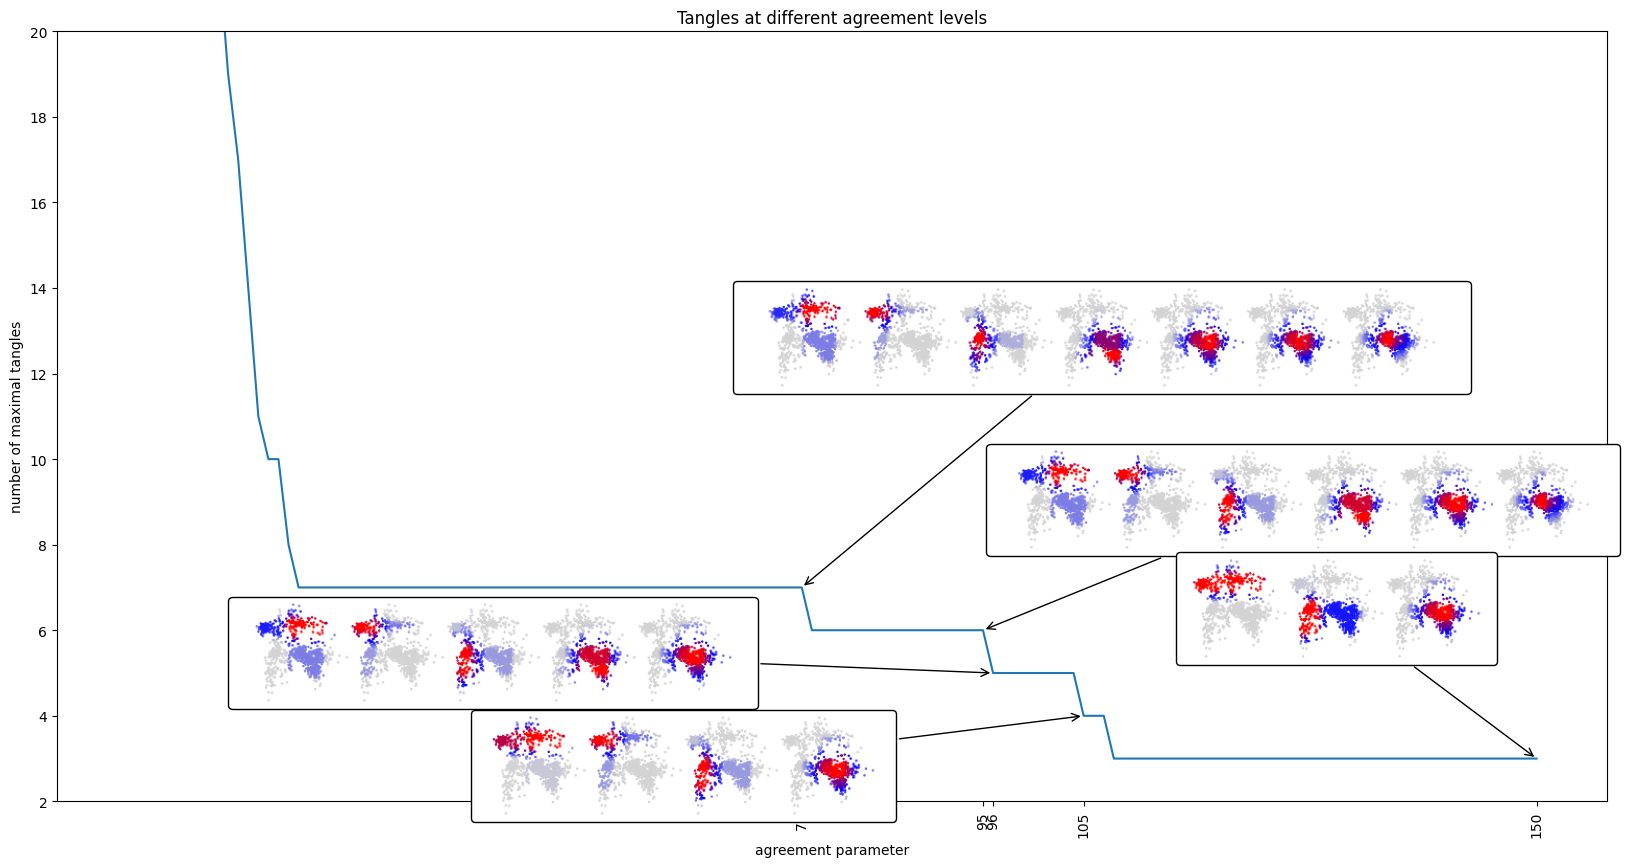

In [62]:
from tangles.util.ui import plot_annotated
from matplotlib.backends.backend_agg import FigureCanvasAgg

agreement_range = range(10,151)

def anno_func(agreement):
    scores = tangles.tangle_score(min_agreement=agreement, normalize='cols')
    scores /= scores.max(axis=0)
    data = np.tile(M,(scores.shape[1],1))
    data[:,0] += ((M[:,0].max()-M[:,0].min()+1) * np.arange(scores.shape[1])).repeat(M.shape[0])
    
    canvas = FigureCanvasAgg(mpl.figure.Figure(figsize=(scores.shape[1], 1)))
    ax = canvas.figure.add_axes((0, 0, 1, 1))
    ax.axis("off")
    ax.scatter(data[:, 0], data[:, 1], c=scores.T.reshape(-1), s=0.5, cmap=cmap)
    canvas.draw()
    return np.array(canvas.renderer.buffer_rgba())
        
fig, ax = plt.subplots(1,1,figsize=(20,10))
ax.set_ylim([2,20])
ax.tick_params(axis='x', labelrotation=90)
plot_annotated(x = agreement_range, y = [len(tangles.tree.maximal_tangles(agreement)) for agreement in agreement_range], 
               annotation_x_positions= [77, 95, 96, 105, 150], annotation_offsets=[(300,250),(320,130),(-500,20),(-400,-50),(-200,150)],
               annotation_func = anno_func, annotation_is_image=True, annotation_zoom=0.75,
               xlabel="agreement parameter", ylabel="number of maximal tangles",
               title = "Tangles at different agreement levels",
               ax = ax)
    


At level $\alpha_{\min} = 150$, we see only three tangles: top, bottom right and bottom left. If we lower the agreement to 105, the top part is further split into left and right part. Continuing to lower the agreement results in a successive refinement of the big cluster in the bottom right. At $\alpha_{\min} = 77$ we are at the same situation as above for agreement $30$. For even lower agreements more and more other tangles are split further, but these tangles often only reflect small density fluctuations in the data.  

For example, at $\alpha_{\min} = 25$, the bottom left cluster is split into two reasonable clusters, at the same time, the top left is split into two regions of different density. This is actually nice, but the differences in scores are tiny and more powerful scoring schemes might be needed.

Text(0.5, 0.98, 'Maximal tangles for agreement 25')

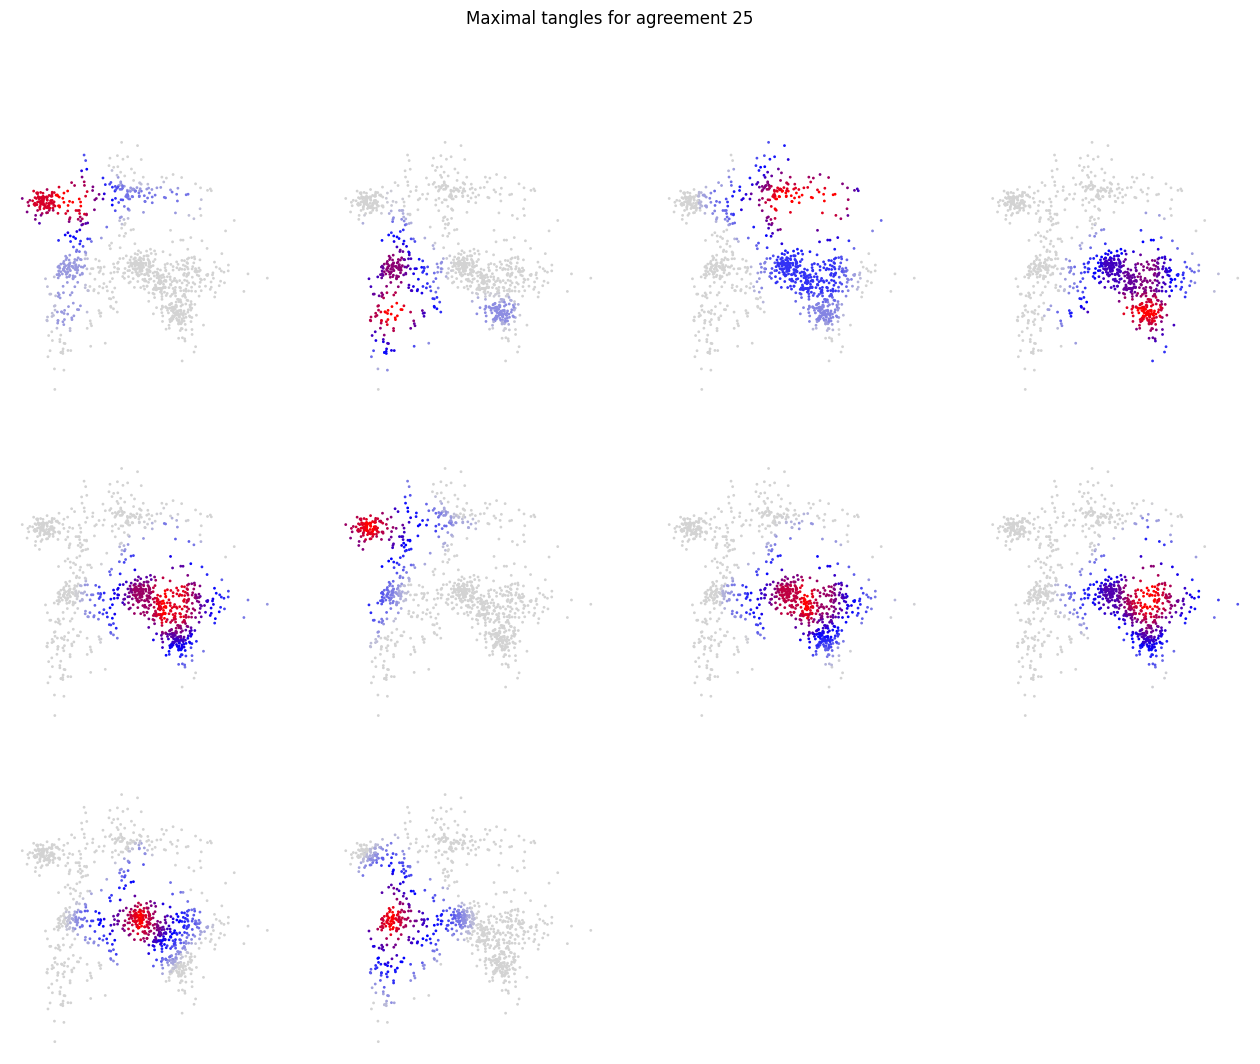

In [63]:
agreement = 25
scores = tangles.tangle_score(min_agreement=agreement, normalize='cols')
fig, axes = plt.subplots(nrows=(r:=int(np.ceil(scores.shape[1]/4))), ncols=4, figsize=(16,r*4))
for i,ax in enumerate(axes.flat):
    if i<scores.shape[1]:
        ax.scatter(M[:, 0], M[:, 1], c=scores[:, i], s=1, cmap = cmap)
        ax.axis("off")
    else:
        ax.set_visible(False)
fig.suptitle(f"Maximal tangles for agreement {agreement}")

## 3. Summary

Often astonishingly simple features can give quite good results. We have seen, that tangles can handle qualitatively diverse feature sets quite effectively. As long as we have *some* features that capture *some* aspects of *some* kind of structure in the data, tangles should be able to detect or at least emphasize it. 

There is a small caveat: This example was a toy example meant for educational purposes. The data set was especially handsome because we could easily visualise it, its structure and even the tangles. This is usually not the case and this is one of the biggest obstacles encountered in (unsupervised) data analysis as a whole and, in particular, even more in tangles. Often, one has to put significant effort in finding out the meaning of a tangle in the context of the data's domain. However, this should not dissuade us from playing with this beautiful technique.
